In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from taylorDiagram import TaylorDiagram

Load Data

In [2]:
STNS = np.loadtxt("../DATA/Stations.txt",dtype='U2')
VNS = np.loadtxt("../DATA/Products.txt",dtype='<U10')

STN_DATA = xr.open_dataarray("../DATA/STN_DATA.nc")
STN_CC = xr.open_dataarray("../DATA/STN_CC.nc")
STN_RMSE = xr.open_dataarray("../DATA/STN_RMSE.nc")

STN_AB = xr.open_dataarray("../DATA/STN_AB.nc")

Separate OBS from EST, and limit to time range of AB

In [3]:
i_d1=STN_AB.datetime[0].values
i_dn=STN_AB.datetime[-1].values

O = STN_DATA.sel(datetime=slice(i_d1, i_dn)).loc[dict(Product="PM")]
sigma_O = O.std(dim=["datetime"])
sigma_Om = sigma_O.mean(dim="Station")

R = STN_DATA.sel(datetime=slice(i_d1, i_dn)).drop_sel(Product=["PM", "TH"])
sigma_R = R.std(dim=["datetime"])
sigma_Rm = sigma_R.mean(dim="Station")

R_CC = xr.corr(O, R, dim="datetime" )
R_CCm = R_CC.mean(dim="Station")

R_E = R - O
R_RMSE = np.sqrt((R_E**2).mean(dim="datetime"))
R_RMSEm = R_RMSE.mean(dim="Station")

Generate data for AB product
- I checked this for a sample, and it works as expected.

In [4]:
sigma_AB = STN_AB.std(dim=["datetime"])
sigma_ABm = sigma_AB.mean(dim="Station")

AB_CC = xr.corr(O, STN_AB, dim="datetime" )
AB_CCm = AB_CC.mean(dim="Station")

Generate index to sort R products by RMSE before plotting

In [5]:
sri = np.argsort(R_RMSEm)

Create markers = "^" and "v" for satellites (need to tell aqua and terra apart), "o" for reanalysis.

In [6]:
i_markers = (["v", "o", "o", "^", "o", "v", "o", "v", "^", "v"])

Create a Taylor plot.

C:\Users\Haneen.Muhammad\AppData\Local\Temp\ipykernel_22168\3308222919.py:17: MatplotlibDeprecationWarning: Passing `apply_theta_transforms=True` (the default) is deprecated since Matplotlib 3.9. Support for this will be removed in Matplotlib in 3.11. To prevent this warning, set `apply_theta_transforms=False`, and make sure to shift theta values before being passed to this transform.
  plt.clabel(contours, inline=1, fontsize=10, fmt='%.2f')


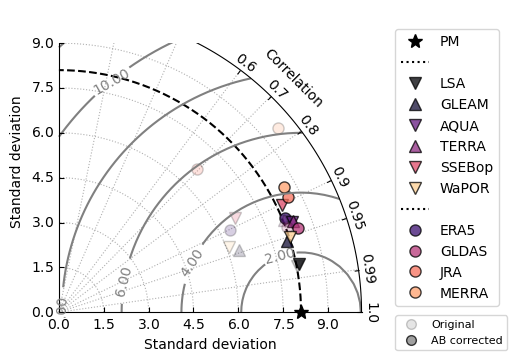

In [7]:
i_colors = plt.matplotlib.cm.magma(np.linspace(0, 1, len(sri)+1))
fig = plt.figure(figsize=(5, 3.5))
# Taylor diagram
dia = TaylorDiagram(sigma_Om.values, fig=fig, extend=False, label="PM", srange=(0, 1.25))
for i in range(len(sri)):
    dia.add_sample(sigma_Rm[sri[i]].values, R_CCm[sri[i]].values,
                       marker=i_markers[sri[i].values], ms=8, ls='',
                       mfc=i_colors[i], mec='k', alpha=0.2)
    dia.add_sample(sigma_ABm[sri[i]].values, AB_CCm[sri[i]].values,
                       marker=i_markers[sri[i].values], ms=8, ls='',
                       mfc=i_colors[i], mec='k', alpha=0.75,
                       label=AB_CCm.Product.values[sri[i]])

dia.add_grid(ls=':')

contours = dia.add_contours(levels=6, colors='0.5')
plt.clabel(contours, inline=1, fontsize=10, fmt='%.2f')

ax = plt.gca()

handles, labels = ax.get_legend_handles_labels()

qwe = plt.Line2D(
    np.array([0, 1]), np.array([0, 1]),
    linestyle=":", color='k'
)


product_handles = [
    handles[0], qwe,
    handles[1], handles[2], handles[4], handles[5], handles[7], handles[10],
    qwe,
    handles[3], handles[6], handles[8], handles[9]
]

product_labels = [
    labels[0], "",
    labels[1], labels[2], labels[4], labels[5], labels[7], labels[10],
    "",
    labels[3], labels[6], labels[8], labels[9]
]

legend1 = ax.legend(
    product_handles,
    product_labels,
    loc='upper left',
    bbox_to_anchor=(1.10, 1.05),   
    borderaxespad=0.0
)

ax.add_artist(legend1)


original_handle = plt.Line2D(
    [], [], marker='o', linestyle='', markersize=7,
    markerfacecolor='0.5', markeredgecolor='k', alpha=0.2
)

ab_handle = plt.Line2D(
    [], [], marker='o', linestyle='', markersize=7,
    markerfacecolor='0.5', markeredgecolor='k', alpha=0.75
)

ax.legend(
    [original_handle, ab_handle],
    ['Original', 'AB corrected'],
    loc='upper left',
    bbox_to_anchor=(1.10, 0.01),  
    borderaxespad=0.0,
    fontsize=8,
    frameon=True
)

plt.tight_layout()

ax.set_ylim(-0.2, 9)

plt.savefig("ET4I_Taylor_AB.png", dpi=300, bbox_inches='tight')